Evaluation Graphs for ANN

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.event_detection import build_detector, collect_default_data_paths, split_train_test
from src.event_detection_pipeline.model_io import load_detector, save_detector
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc as calc_auc,
    precision_recall_curve,
    average_precision_score,
)

In [3]:
data_dir = ROOT / 'src' / 'data'
paths = collect_default_data_paths(data_dir)
train_paths, test_paths = split_train_test(paths)

print(f'Loaded {len(paths)} SCADA files')
print(f'Train files: {len(train_paths)} | Test files: {len(test_paths)}')

Loaded 20 SCADA files
Train files: 14 | Test files: 6


In [4]:
# confusion matrix for event detection
history = 5
epochs = 12
batch_size = 256
learning_rate = 1e-3

candidate_hidden_sizes = [
    #(32,),
    #(64, 32),
    (128, 64),
    #(128, 64, 32),
]

In [5]:
# RUN only if you want to overwrite the current detector performance results

for hidden_sizes in candidate_hidden_sizes:
    candidate_detector = build_detector(
        train_paths,
        history=history,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=learning_rate,
        hidden_sizes=hidden_sizes,
    )

    save_detector(candidate_detector, directory=f"../results/2026-06-29/detector_{'-'.join(map(str, hidden_sizes))}")


All files saved to /Users/esther/dev/Arsenic-Detection/src/results/2026-06-29/detector_128-64/


In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.event_detection_pipeline.evaluation import (
    plot_roc_curve_event_detection,
    plot_roc_curve_chlorine_prediction,
    plot_precision_recall_curve,
)


def plot_metrics(result, title_prefix="", chlorine_indices=None):
    
    print("Chlorine indices:", chlorine_indices)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Confusion Matrix
    cm = confusion_matrix(
        result.event_flags.astype(bool),
        result.alarms.astype(bool),
        labels=[False, True],
        normalize="all",
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Normal", "Event"],
    )
    disp.plot(
        ax=axes[0, 0],
        colorbar=False,
        values_format=".2f",
    )
    axes[0, 0].set_title(f"{title_prefix}Confusion Matrix")

    # 2. Event detection ROC
    plot_roc_curve_event_detection(
        result,
        title=f"{title_prefix}Event Detection ROC",
        ax=axes[0, 1],
    )

    # 3. Chlorine prediction ROC
    plot_roc_curve_chlorine_prediction(
        result,
        chlorine_indices=chlorine_indices,
        title=f"{title_prefix}Chlorine Prediction ROC",
        ax=axes[1, 0],
    )

    # 4. Precision-Recall curve
    plot_precision_recall_curve(
        result,
        title=f"{title_prefix}Precision-Recall Curve",
        ax=axes[1, 1],
    )

    plt.tight_layout()
    plt.show()
    return fig, axes


Detector successfully loaded from /Users/esther/dev/Arsenic-Detection/src/results/2026-06-29/detector_128-64/
Results for detector with hidden sizes: 128-64


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
scada_data_4.npz,0.0,0.951195,0.0,0.0,0.0,NaN,0
scada_data_5.npz,0.0,0.951195,0.0,0.0,0.0,NaN,0
scada_data_6.npz,0.0,0.951195,0.0,0.0,0.0,NaN,0


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
mean,0.0,9.511952e-01,0.0,0.0,0.0,NaN,0.0
std,0.0,1.359740e-16,0.0,0.0,0.0,NaN,0.0


Chlorine indices: [0, 1, 2, 3, 4, 5, 6, 7, 8]


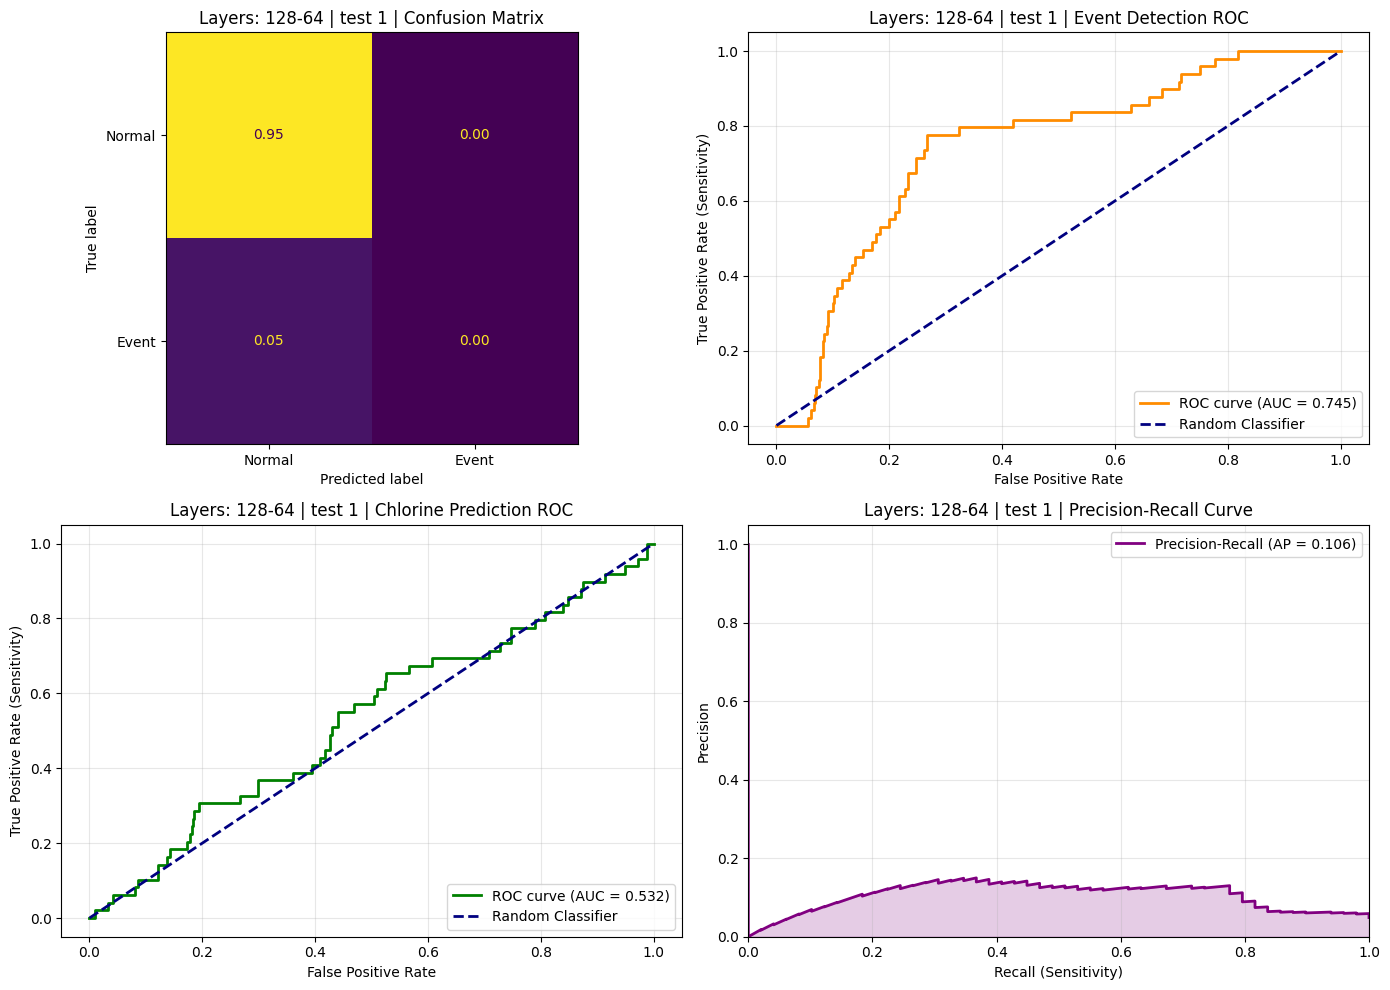

Chlorine indices: [0, 1, 2, 3, 4, 5, 6, 7, 8]


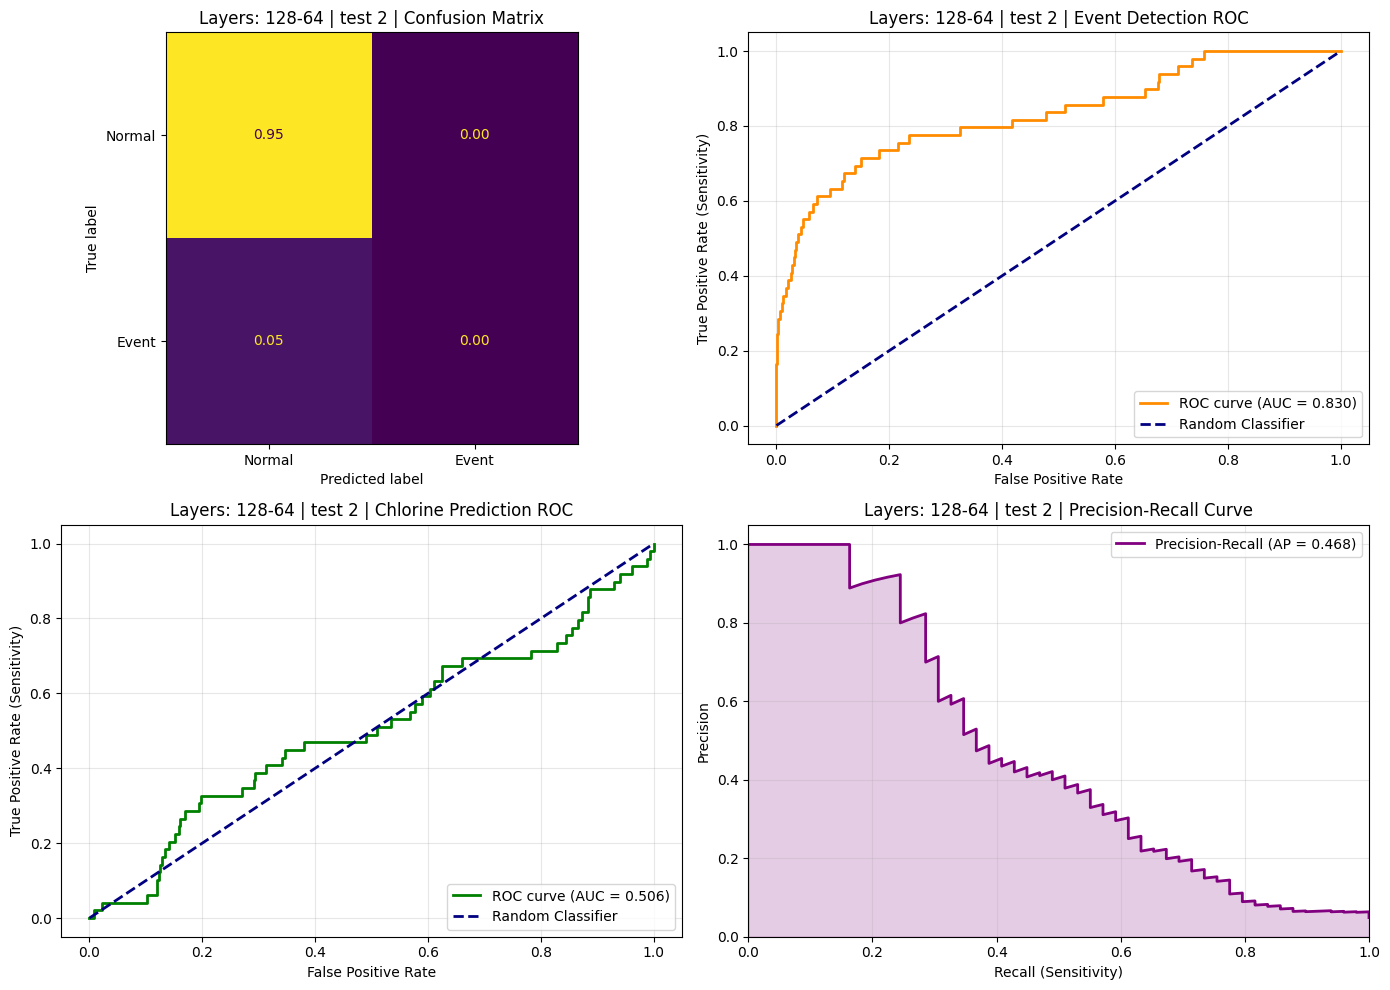

Chlorine indices: [0, 1, 2, 3, 4, 5, 6, 7, 8]


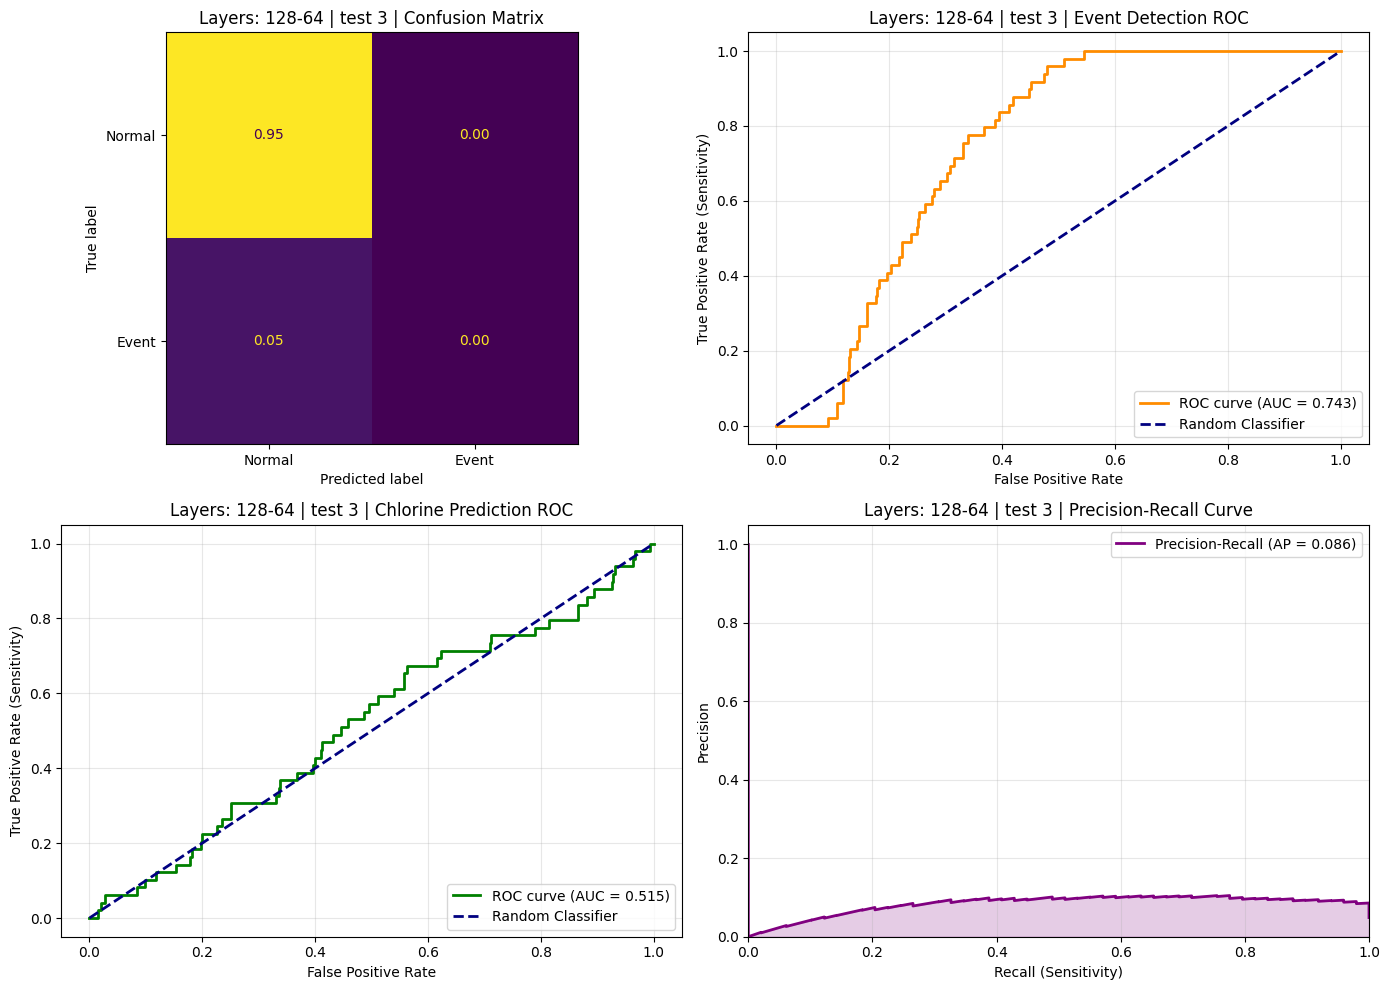

,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
hidden_sizes,,,,,,,
128-64,0.0,0.951195,0.0,0.0,0.0,NaN,0.0


In [8]:
all_detector_summaries = []
# Use candidate_hidden_sizes to load the saved detectors and run tests on them.
for hidden_sizes in candidate_hidden_sizes:
    hidden_sizes_label = "-".join(map(str, hidden_sizes))
    detector = load_detector(
        directory=f"../results/2026-06-29/detector_{hidden_sizes_label}",
        device="mps",
    )

    selected_test_paths = test_paths[:3]
    results = [detector.detect(path) for path in selected_test_paths]

    print(f"Results for detector with hidden sizes: {hidden_sizes_label}")

    # Keep the three test sets separated.
    summary_df = pd.DataFrame(
        [result.summary() for result in results],
        index=[path.name for path in selected_test_paths],
    )
    display(summary_df)

    # Aggregate metrics across the three test sets.
    aggregated_summary = pd.DataFrame(
        [
            summary_df.mean(numeric_only=True),
            summary_df.std(numeric_only=True),
        ],
        index=["mean", "std"],
    )
    display(aggregated_summary)

    detector_summary = summary_df.mean(numeric_only=True).to_dict()
    detector_summary["hidden_sizes"] = hidden_sizes_label
    all_detector_summaries.append(detector_summary)

    # Plot each test set separately, because each DetectionResult has its own timeline.
    for i, result in enumerate(results):
        plot_metrics(
            result,
            title_prefix=f"Layers: {hidden_sizes_label} | test {i+1} | ",
            chlorine_indices=list(range(result.actual.shape[1]))
        )

# Compare all detectors by their mean metrics.
all_detector_summaries_df = pd.DataFrame(all_detector_summaries).set_index("hidden_sizes")
display(all_detector_summaries_df)


Detector successfully loaded from /Users/esther/dev/Arsenic-Detection/src/results/2026-06-29/detector_128-64/
Results for detector with hidden sizes: 128-64


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
scada_data_4.npz,0.0,0.951195,0.0,0.0,0.0,NaN,0
scada_data_5.npz,0.0,0.951195,0.0,0.0,0.0,NaN,0
scada_data_6.npz,0.0,0.951195,0.0,0.0,0.0,NaN,0


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
mean,0.0,9.511952e-01,0.0,0.0,0.0,NaN,0.0
std,0.0,1.359740e-16,0.0,0.0,0.0,NaN,0.0


Chlorine indices: [8, 3, 5]


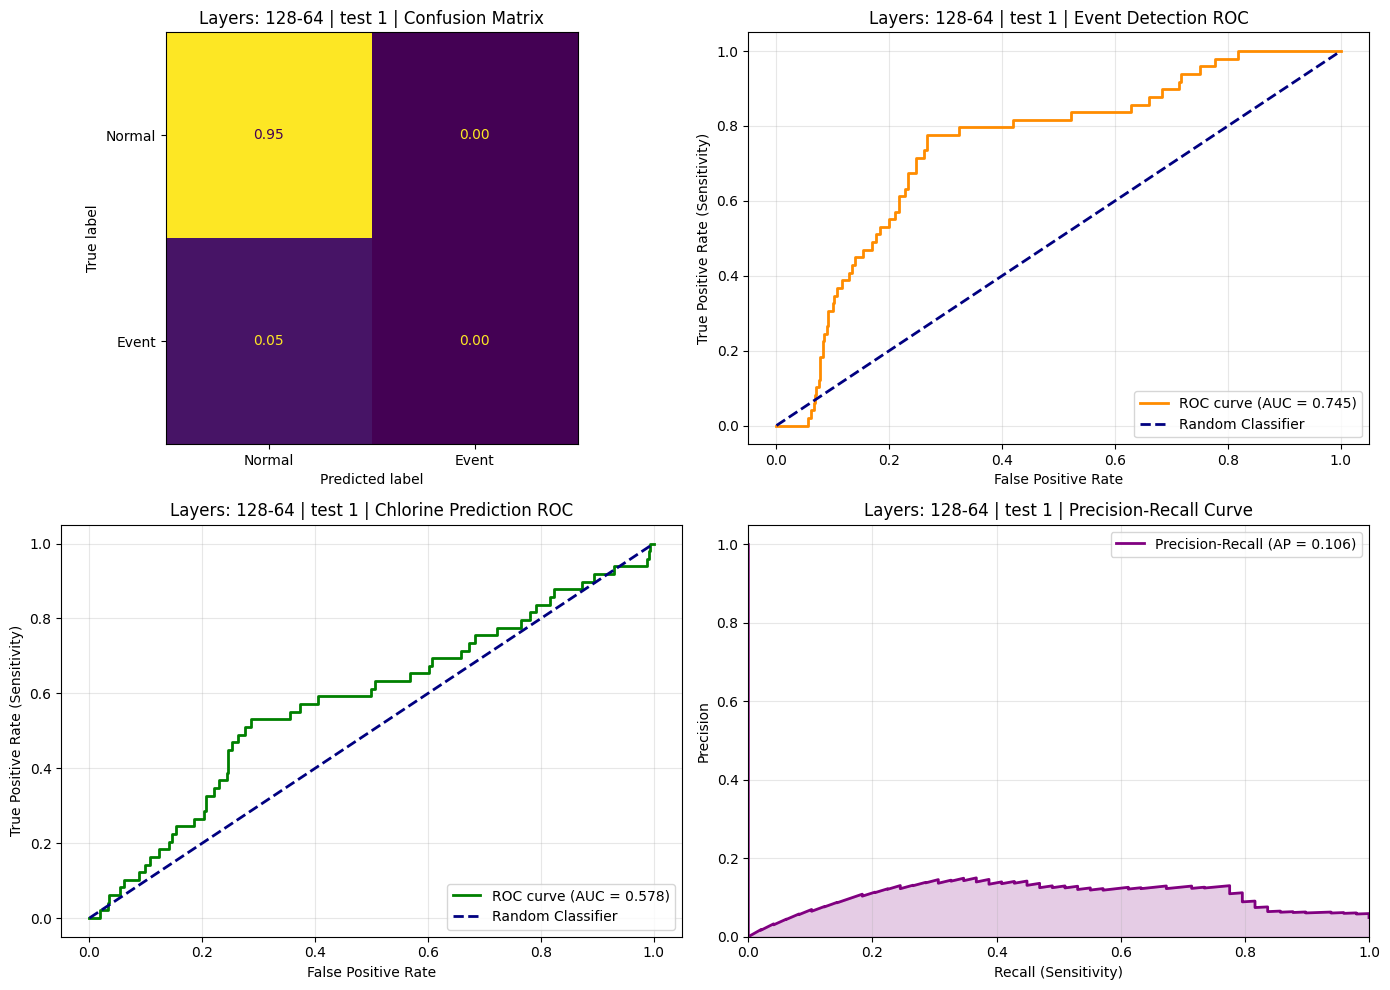

Chlorine indices: [8, 3, 5]


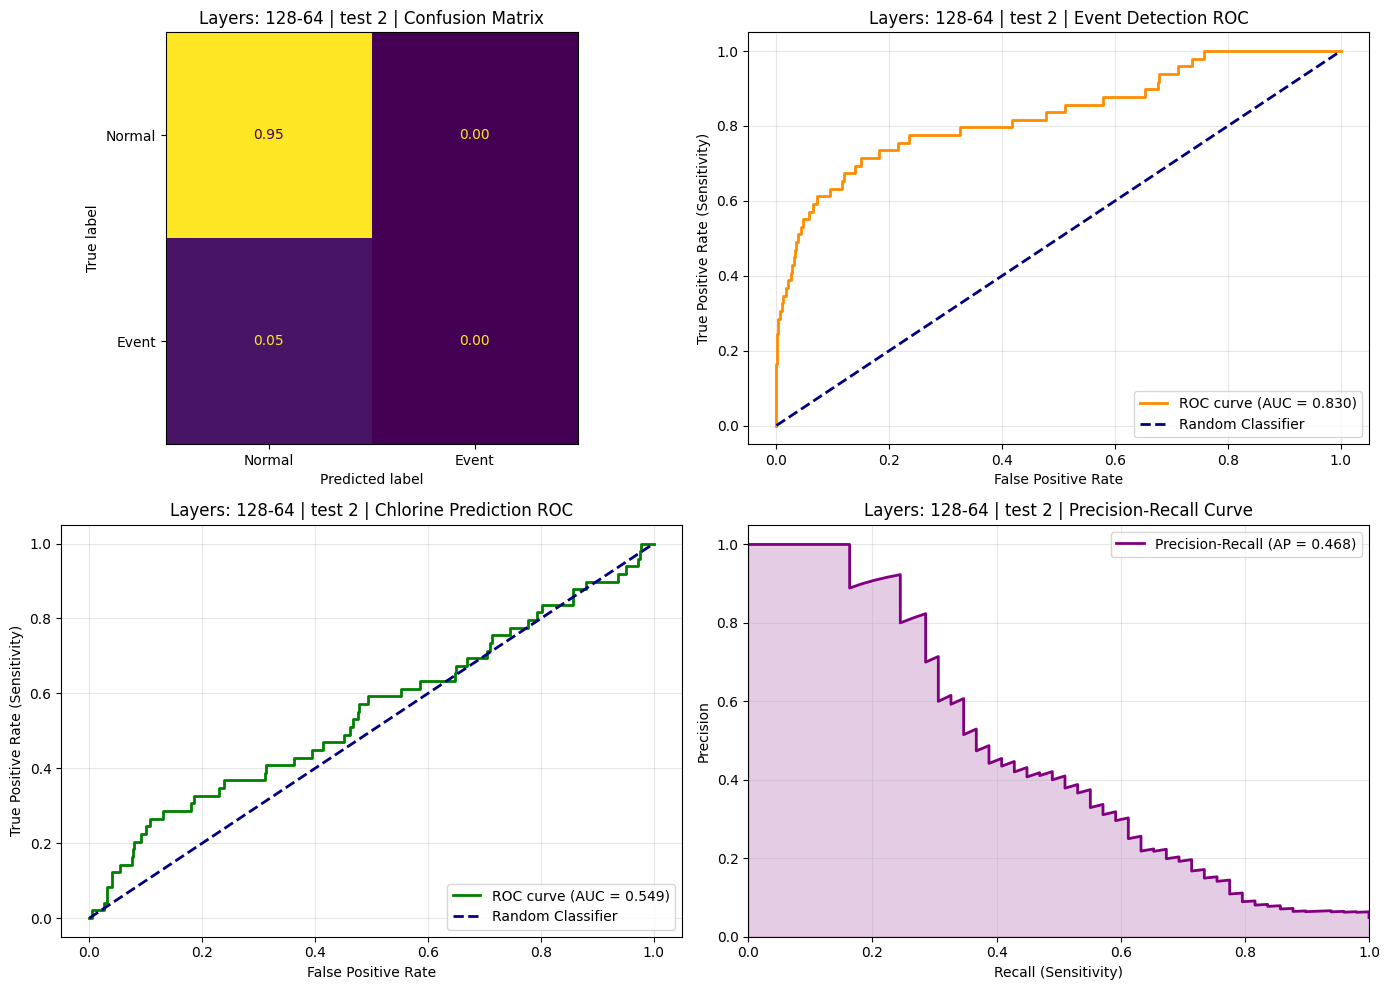

Chlorine indices: [8, 3, 5]


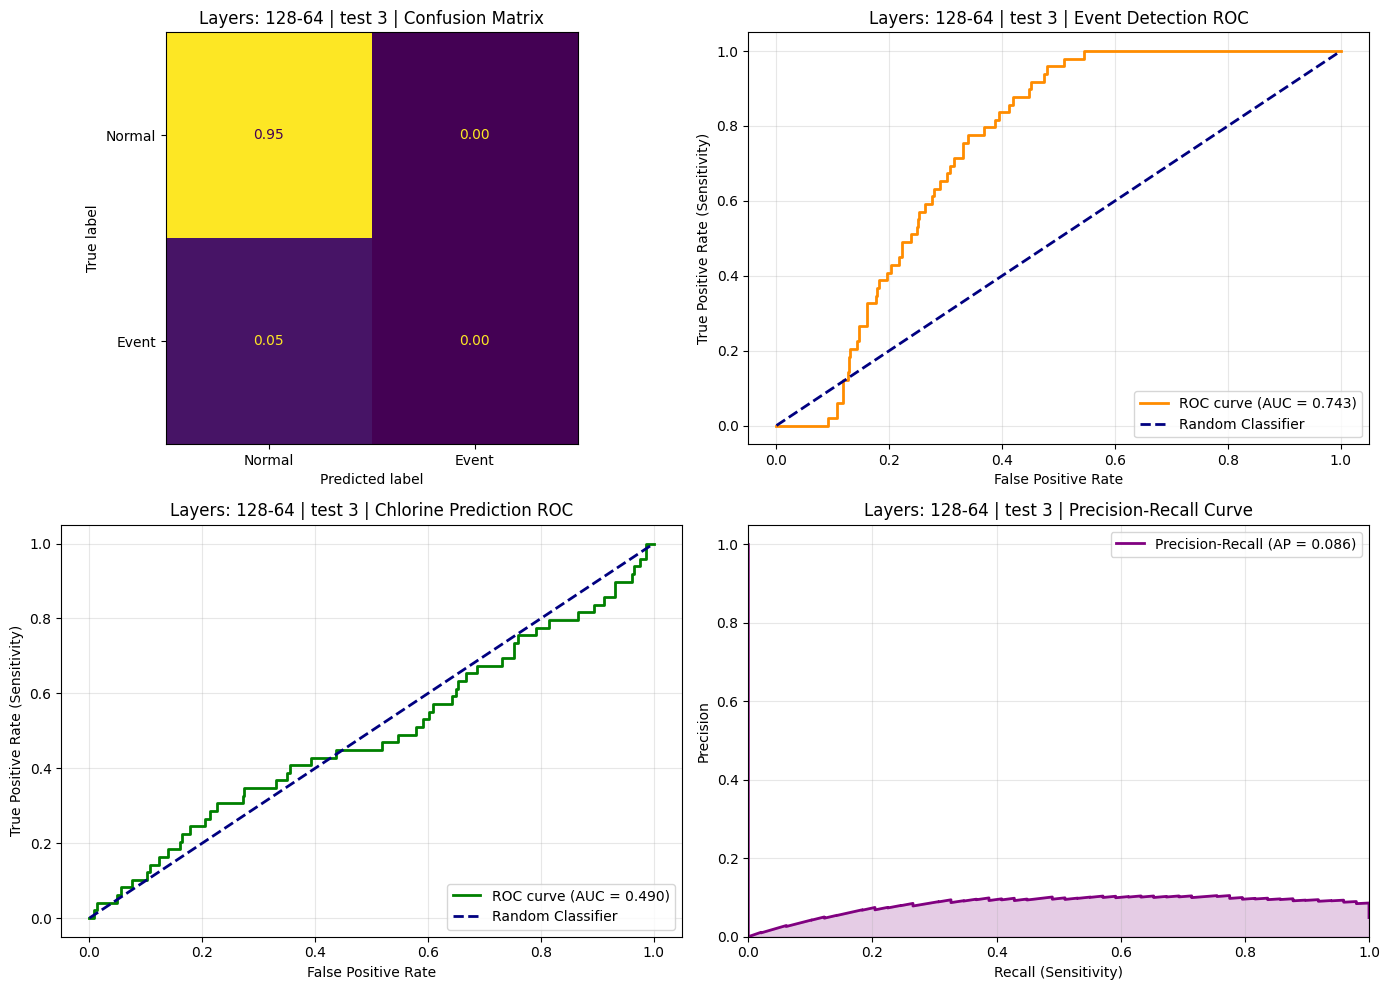

Results for detector with hidden sizes: 128-64


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
scada_data_4.npz,0.0,0.951195,0.0,0.0,0.0,NaN,0
scada_data_5.npz,0.0,0.951195,0.0,0.0,0.0,NaN,0
scada_data_6.npz,0.0,0.951195,0.0,0.0,0.0,NaN,0


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
mean,0.0,9.511952e-01,0.0,0.0,0.0,NaN,0.0
std,0.0,1.359740e-16,0.0,0.0,0.0,NaN,0.0


Chlorine indices: [1, 0, 6]


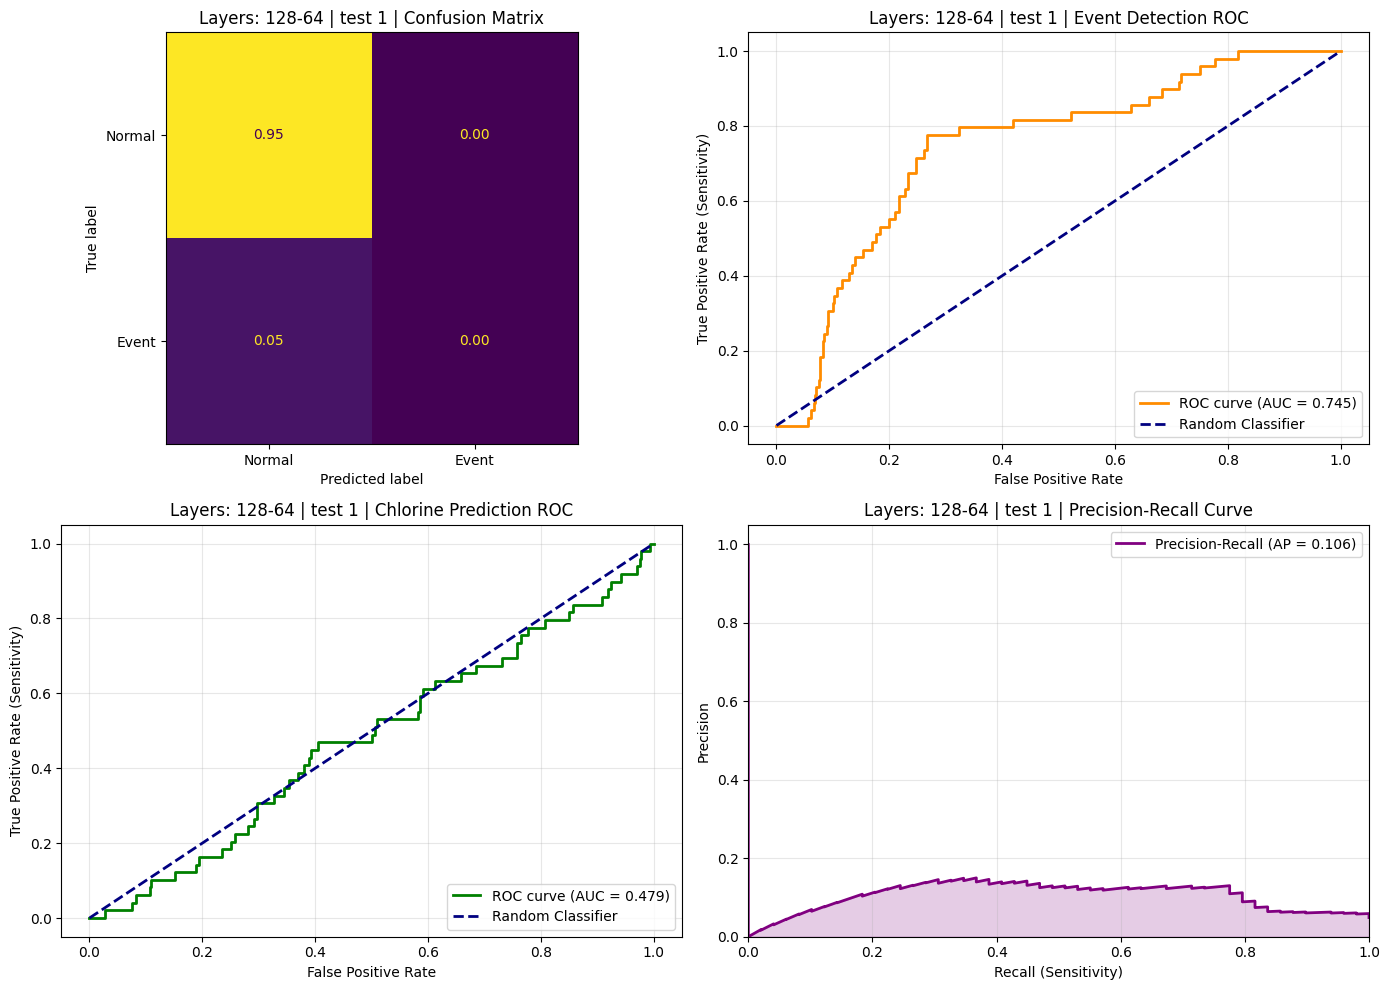

Chlorine indices: [1, 0, 6]


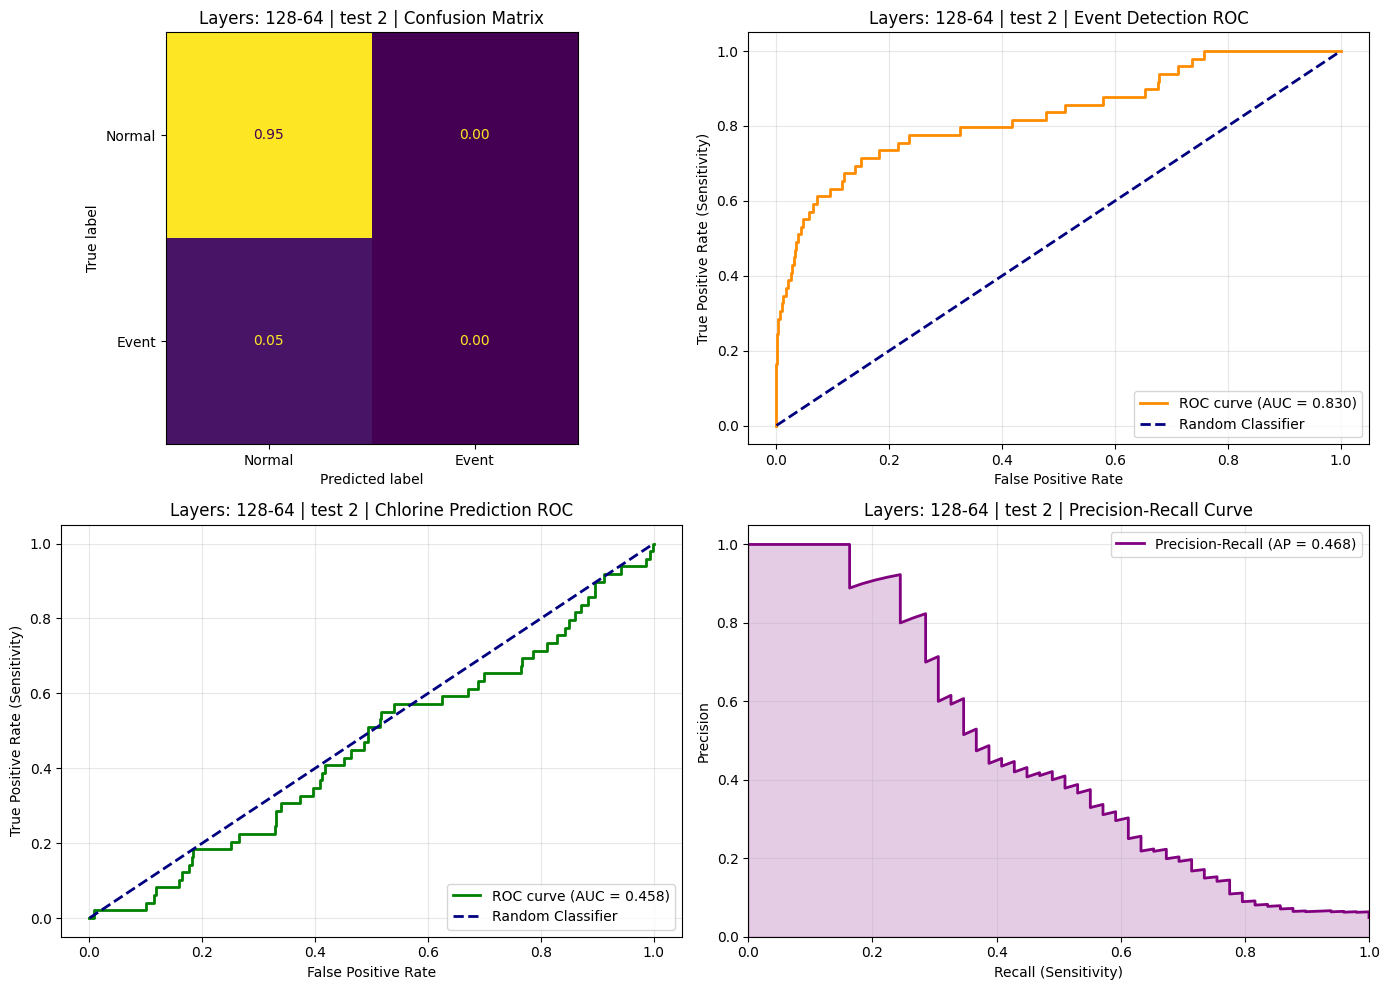

Chlorine indices: [1, 0, 6]


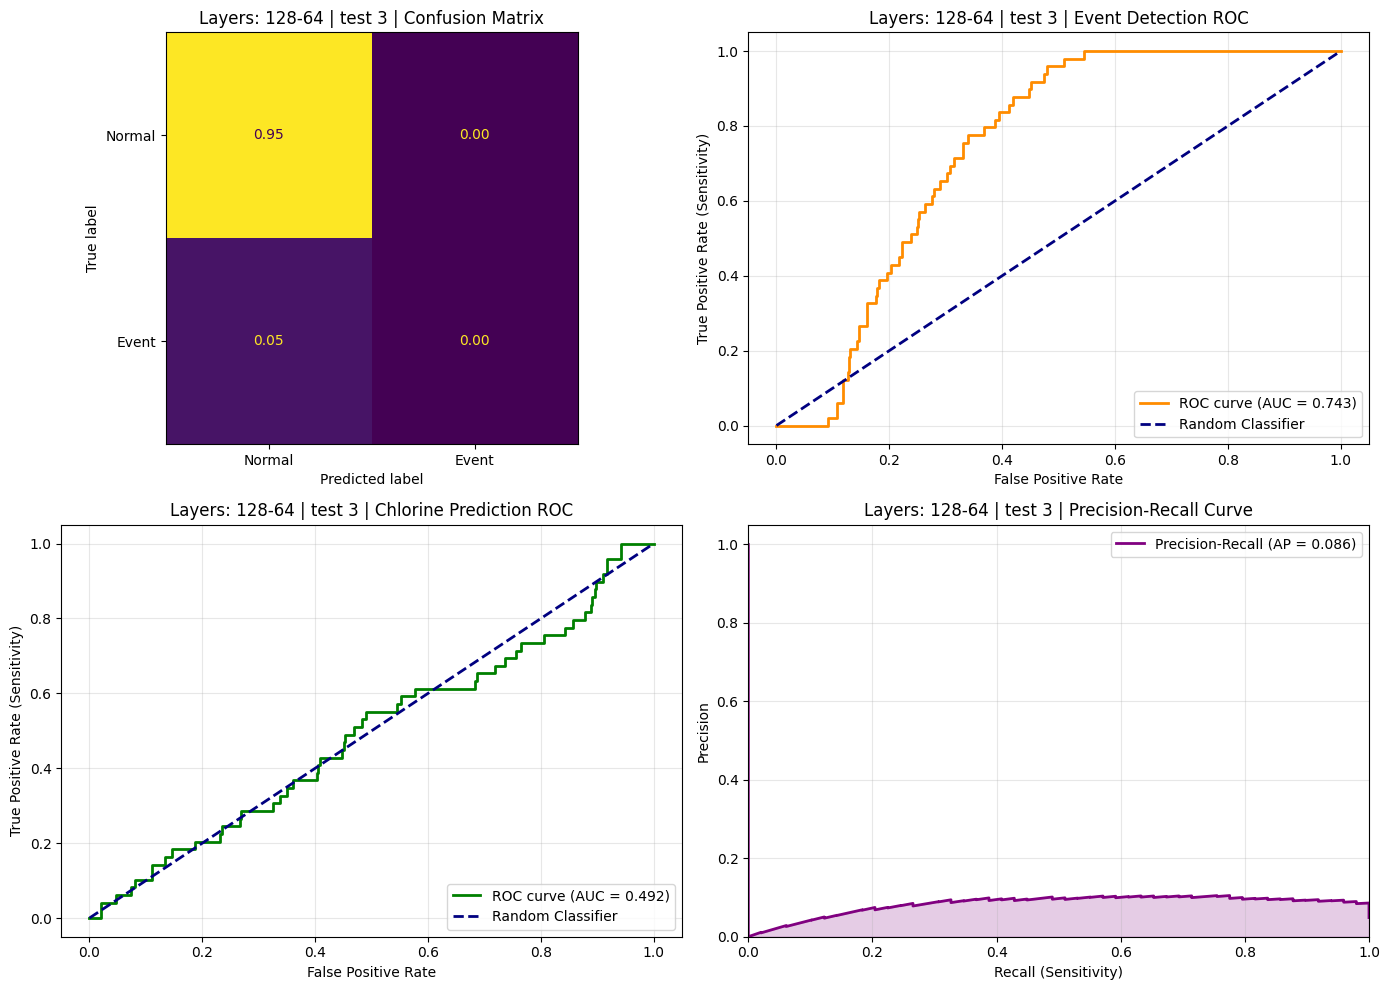

Results for detector with hidden sizes: 128-64


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
scada_data_4.npz,0.0,0.951195,0.0,0.0,0.0,NaN,0
scada_data_5.npz,0.0,0.951195,0.0,0.0,0.0,NaN,0
scada_data_6.npz,0.0,0.951195,0.0,0.0,0.0,NaN,0


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
mean,0.0,9.511952e-01,0.0,0.0,0.0,NaN,0.0
std,0.0,1.359740e-16,0.0,0.0,0.0,NaN,0.0


Chlorine indices: [8, 7, 3]


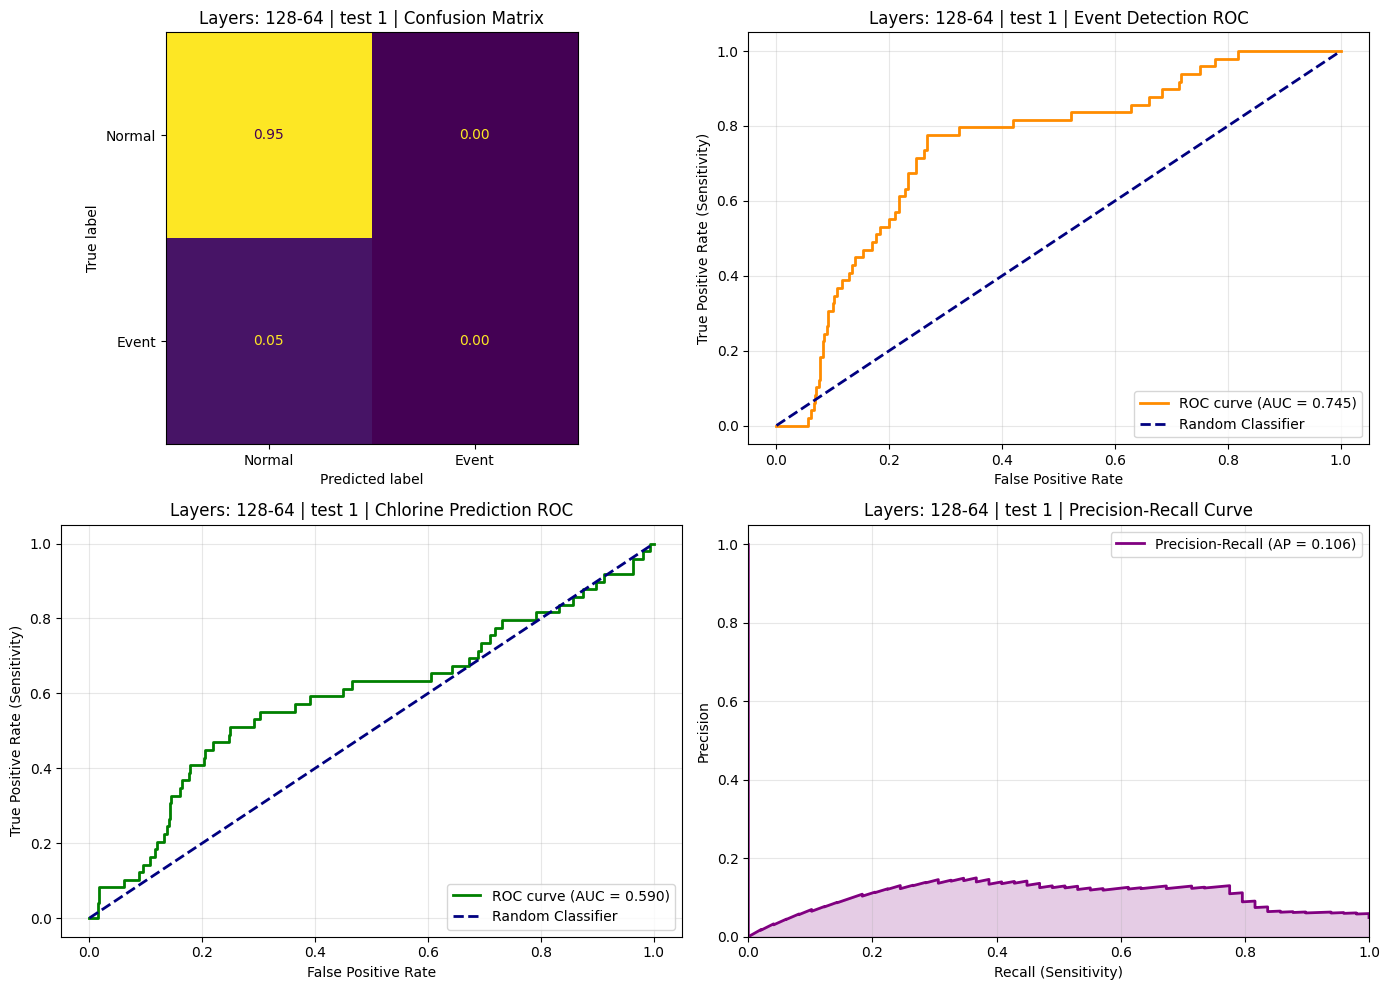

Chlorine indices: [8, 7, 3]


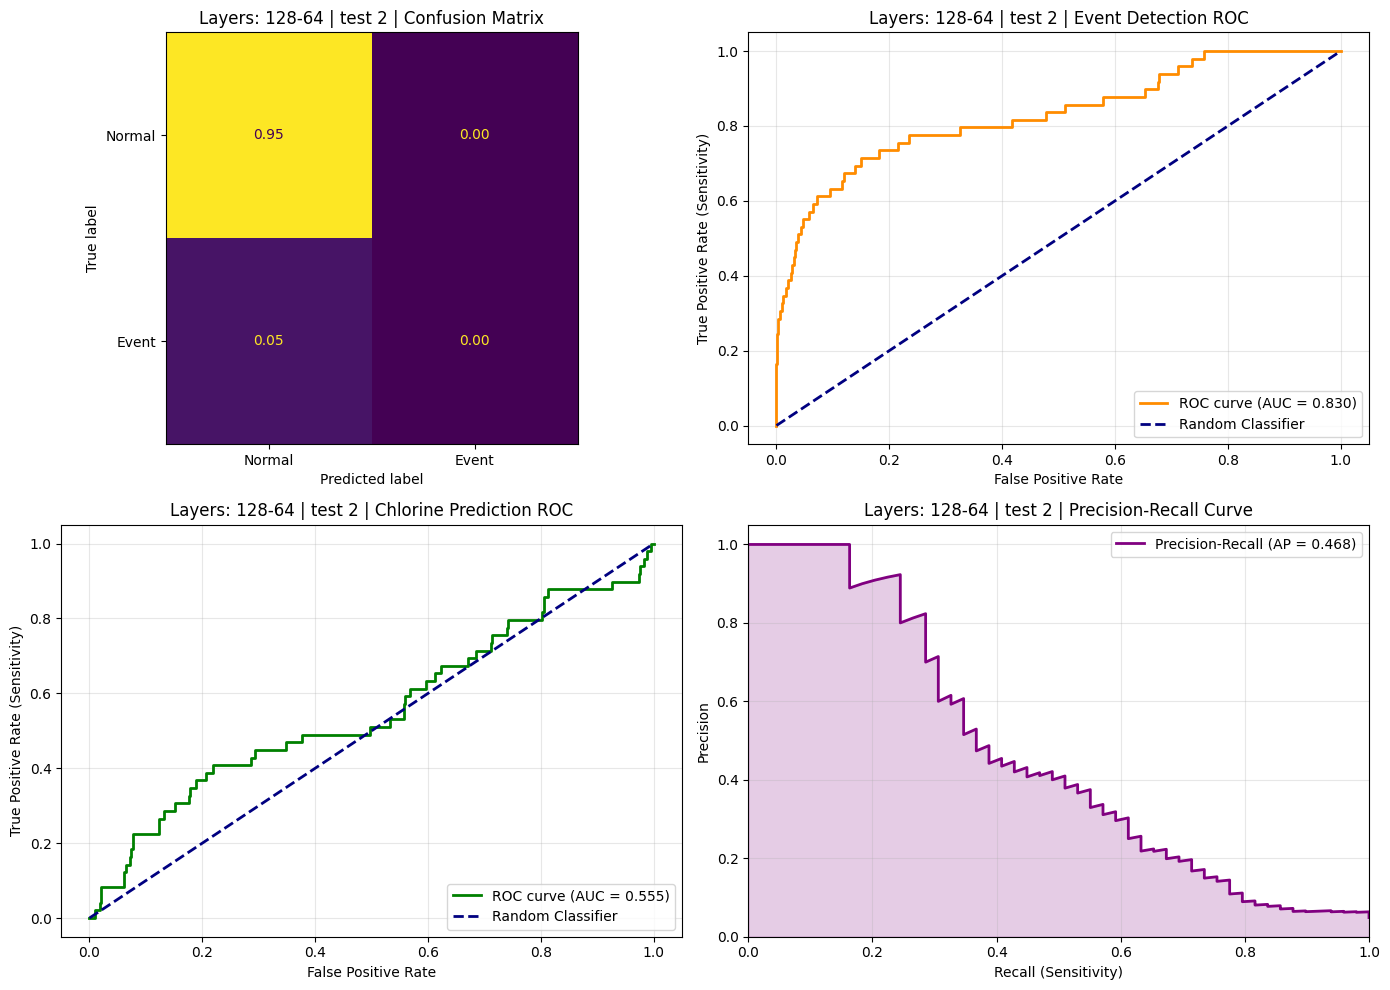

Chlorine indices: [8, 7, 3]


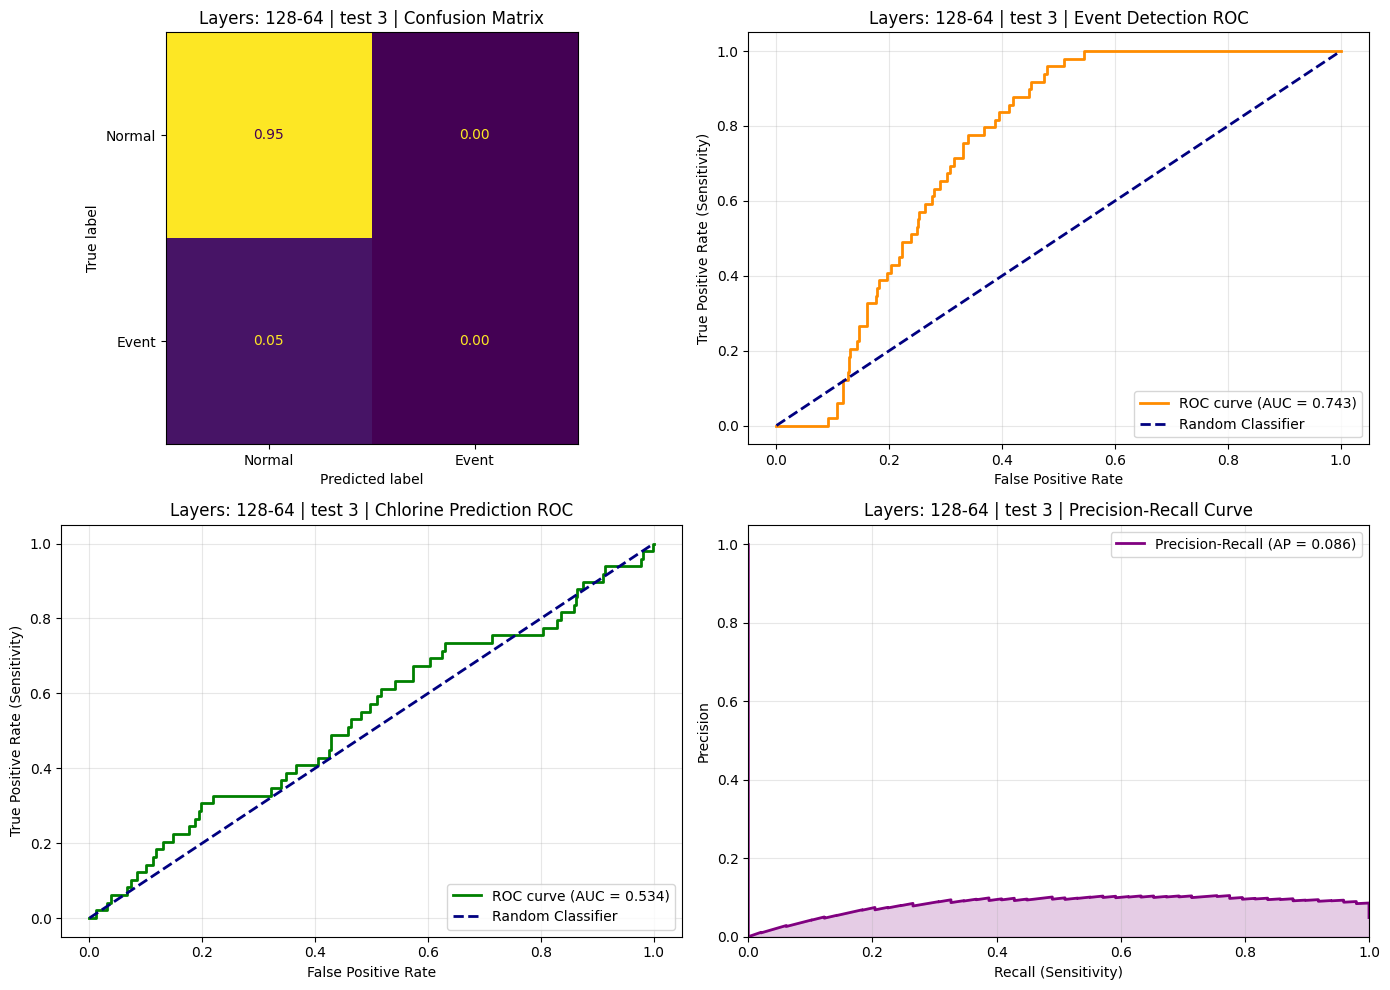

In [9]:
import random

# plot just with 128 - 64 layers but with a few chlorine sensors combinations
detector = load_detector(
    directory=f"../results/2026-06-29/detector_128-64",
    device="mps",
)

#generate 3 random combinations of 3 chlorine output channels
chlorine_sensor_count = detector.scalers.target_mean.shape[0]
chlorine_indices_combinations = [random.sample(range(chlorine_sensor_count), 3) for _ in range(3)]

for chlorine_indices in chlorine_indices_combinations:
    selected_test_paths = test_paths[:3]
    results = [detector.detect(path) for path in selected_test_paths]

    print(f"Results for detector with hidden sizes: {hidden_sizes_label}")

    # Keep the three test sets separated.
    summary_df = pd.DataFrame(
        [result.summary() for result in results],
        index=[path.name for path in selected_test_paths],
    )
    display(summary_df)

    # Aggregate metrics across the three test sets.
    aggregated_summary = pd.DataFrame(
        [
            summary_df.mean(numeric_only=True),
            summary_df.std(numeric_only=True),
        ],
        index=["mean", "std"],
    )
    display(aggregated_summary)

    detector_summary = summary_df.mean(numeric_only=True).to_dict()
    detector_summary["hidden_sizes"] = hidden_sizes_label
    all_detector_summaries.append(detector_summary)

    # Plot each test set separately, because each DetectionResult has its own timeline.
    for i, result in enumerate(results):
        plot_metrics(
            result,
            title_prefix=f"Layers: {hidden_sizes_label} | test {i+1} | ",
            chlorine_indices=chlorine_indices
        )